In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(67)

def load_and_clean(filename):
    return np.loadtxt(filename, skiprows=2)

data_x = load_and_clean('x24x24.txt')
data_y = load_and_clean('y24x24.txt')
data_z = load_and_clean('z24x24.txt')
full_data = np.vstack([data_x, data_y, data_z])

X = full_data[:, :576]
y = full_data[:, 578]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=67,
    stratify=y           # photos of a person will be in both sets
)

In [2]:
from data_augumentation import augment_df
X_new, Y_new = augment_df(X_train, y_train, min_target=110, max_target=155)
unique, c = np.unique(Y_new, return_counts=True)
c

array([122, 150, 110, 110, 110, 110, 155, 110, 147, 110, 110, 147, 126,
       155, 110, 110, 110, 110, 113, 110, 110, 122, 110, 122, 155, 125,
       118, 146, 155, 110, 110, 110, 110, 149, 114, 110, 110, 110, 110,
       110, 146, 136, 155, 155, 110, 137, 138, 110])

In [3]:
df_aug = pd.DataFrame({'class':unique, 'count':c})
df_aug.head()

,class,count
0,0.0,122
1,1.0,150
2,2.0,110
3,3.0,110
4,4.0,110


Text(0.5, 0, 'class name')

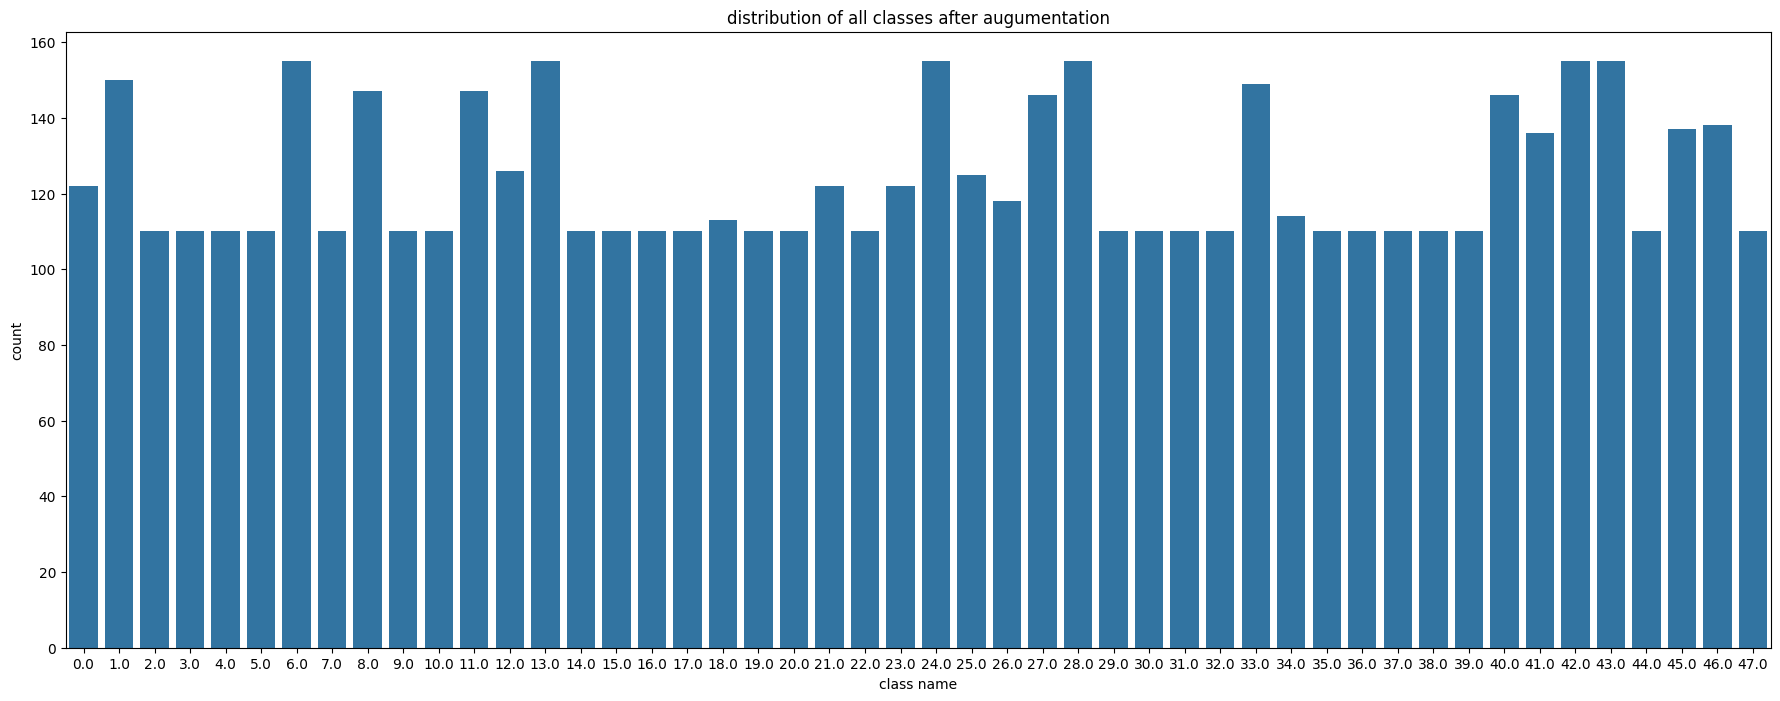

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(22,8))
sns.barplot(data=df_aug, x='class', y='count')
plt.title("distribution of all classes after augumentation")
plt.xlabel('class name')

In [ ]:
import sklearn
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

print(sklearn.__version__)
# weak_learner = DecisionTreeClassifier(max_depth=10, min_samples_leaf=3, min_samples_split=3,criterion='gini', random_state=67)
# n_estimators = 200

# adaboost_clf = AdaBoostClassifier(
#     estimator=weak_learner,
#     n_estimators=n_estimators,
#     random_state=67,
#     learning_rate=0.1
# ).fit(X_new, Y_new)


NameError: name 'sklearn' is not defined

In [ ]:
y_pred=adaboost_clf.predict(X_test)

In [ ]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "testue": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average="weighted"),
        recall_score(y_test, y_pred, average="weighted"),
        f1_score(y_test, y_pred, average="weighted")
    ]
})

metrics_df["testue"] = metrics_df["testue"].round(4)
display(metrics_df)

,Metric,Value
0,Accuracy,0.6196
1,Precision,0.6593
2,Recall,0.6196
3,F1,0.6224


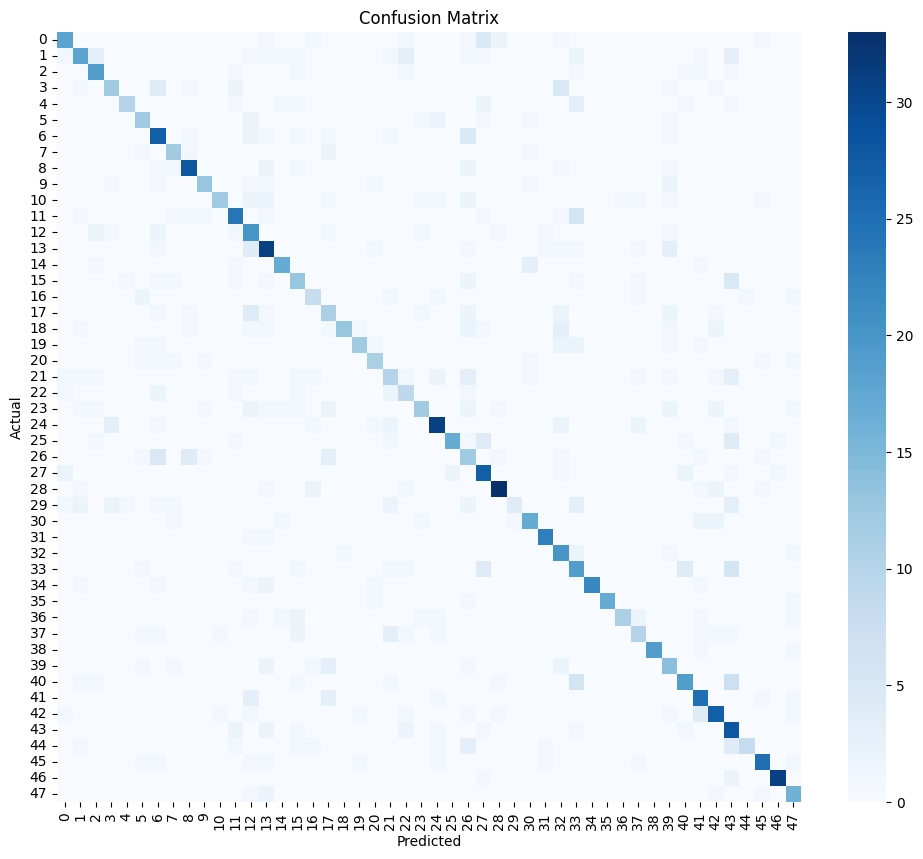

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
accuracy = np.mean(y_pred==y_test)
accuracy

np.float64(0.6196049743964887)

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

df_report = pd.DataFrame(report).T


display(
    df_report.iloc[:-3].sort_values("f1-score")
)

,precision,recall,f1-score,support
29.0,0.800000,0.181818,0.296296,22.0
26.0,0.266667,0.400000,0.320000,30.0
21.0,0.400000,0.333333,0.363636,30.0
17.0,0.392857,0.423077,0.407407,26.0
33.0,0.404255,0.500000,0.447059,38.0
15.0,0.448276,0.481481,0.464286,27.0
37.0,0.500000,0.434783,0.465116,23.0
22.0,0.428571,0.529412,0.473684,17.0
39.0,0.411765,0.560000,0.474576,25.0
23.0,0.666667,0.400000,0.500000,30.0


Text(0.5, 0, 'class name')

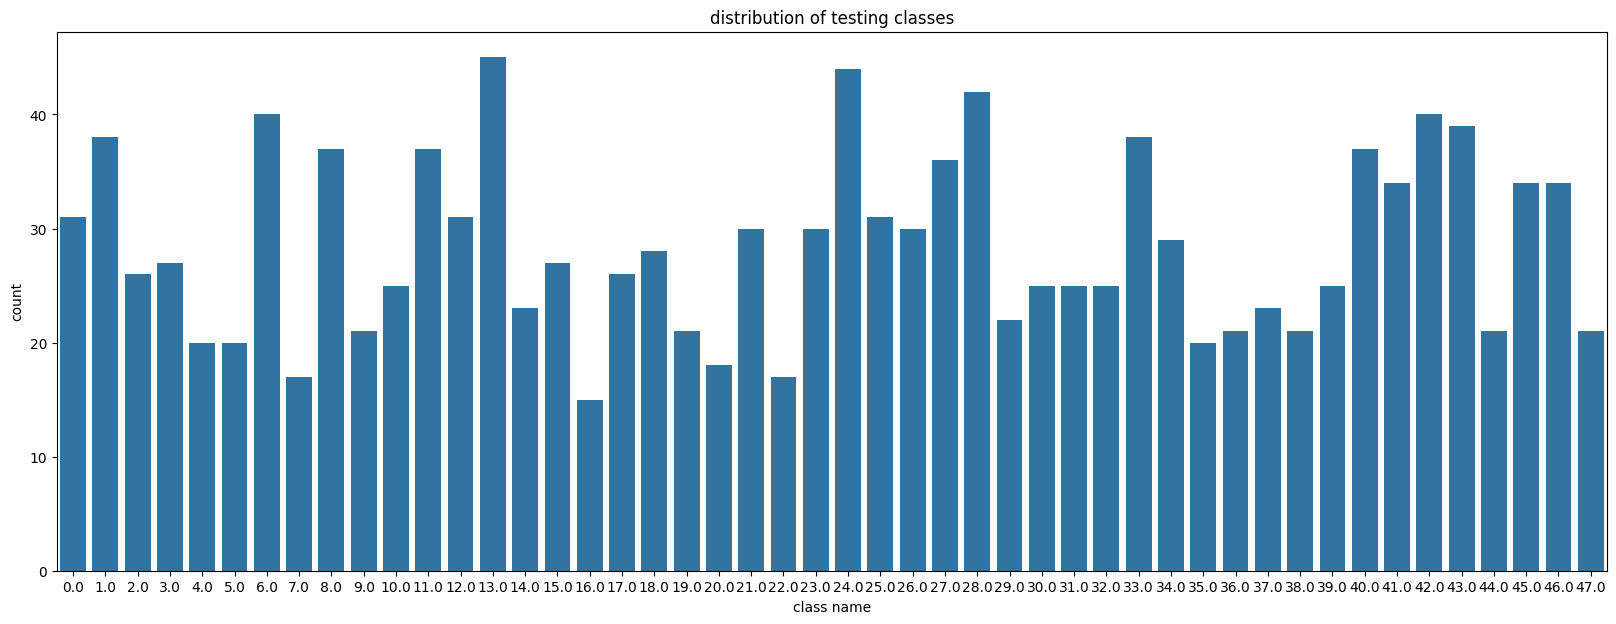

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(20,7))
sns.countplot(x=y_test)
plt.title("distribution of testing classes")
plt.xlabel('class name')

Text(0.5, 0, 'class name')

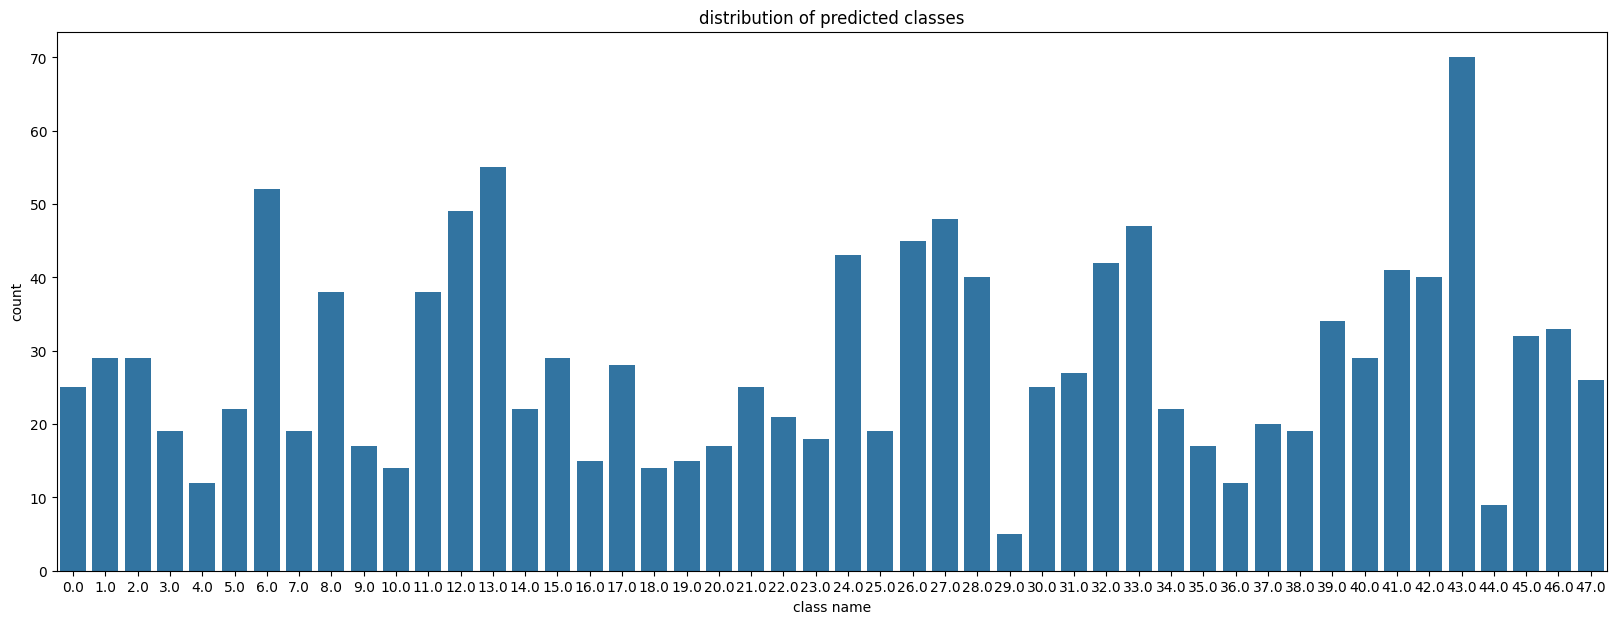

In [ ]:
plt.figure(figsize=(20,7))
sns.countplot(x=y_pred)
plt.title("distribution of predicted classes")
plt.xlabel('class name')